# Example 11: Lunar Lander Navigation with IMU, Altimeter, Crater Bearings, and LunaNet

A lunar lander on powered descent to a south-pole site navigates with an error-state INS **multiplicative EKF (MEKF)** that fuses a full **IMU** (Kalibr noise model), a **nadir radar altimeter** (height above DEM terrain), **crater-landmark bearings** (terrain-relative navigation against a synthetic crater map), and **LunaNet / LANS pseudoranges**, estimating the IMU biases online. Like Example 10 it is built on LuPNT's **agent-based architecture**:

- a **`World`** — the shared environment (frame `MOON_PA`, Moon gravity, the LOLA DEM site).
- a thin **`Lander`** agent hosting **two applications**: a **`LanderGncApp`** (guidance/control) that owns the descent truth trajectory (a built-in smoothstep, or a guidance-law trajectory supplied via `LanderGncApp.set_reference_trajectory_enu`) and writes the lander truth state, and a **`LanderNavApp`** (the INS MEKF) that reads that truth to synthesize the crater map + measurements each epoch from the `World`.

The scenario lives in `configs/lander_nav.yaml`. We run it **once, in a standalone script** (full-sensor descent plus a sensor ablation), and cache the results as CSV; this notebook reads and plots them.

> **Run the simulation first** (from the repo root):
> ```bash
> python python/examples/ex11_run_lander_nav.py
> ```
> This writes CSVs to `output/python_examples/ex11_data/`. Re-run it whenever you change `configs/lander_nav.yaml`.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def zoom_ylim(ax, *series, frac=0.4, pad=1.4):
    """Set a symmetric y-limit to the post-convergence range (last 1-frac of the run) of the
    given series, so the plot illustrates the converged behavior rather than the large initial
    transient."""
    h = int(len(series[0]) * frac)
    m = max(float(np.nanmax(np.abs(np.asarray(s)[h:]))) for s in series)
    if m > 0:
        ax.set_ylim(-pad * m, pad * m)


# Seed from the shipped data/LuPNT_data/examples/ex11_data if not already present.
import sys as _sys
from pathlib import Path as _Path

for _p in [_Path.cwd(), *_Path.cwd().parents]:
    if (_p / "python" / "examples" / "_example_data.py").exists():
        _sys.path.insert(0, str(_p / "python" / "examples"))
        break
from _example_data import seed_example_output

DATA = seed_example_output("ex11_data")
assert (
    DATA / "meta.json"
).exists(), (
    "Run `python python/examples/ex11_run_lander_nav.py` first to generate ex11_data/."
)

meta = json.load(open(DATA / "meta.json"))
s = pd.read_csv(DATA / "series_all.csv")
craters = pd.read_csv(DATA / "craters.csv")
ablation = pd.read_csv(DATA / "ablation.csv")
dem_x = np.load(DATA / "dem_x.npy")
dem_y = np.load(DATA / "dem_y.npy")
dem_z = np.load(DATA / "dem_elevation.npy")

t = s["t_s"].values
print(
    f"Site: {meta['site_id']} ({meta['site_name']})  epochs={len(s)}  dt={meta['dt_s']} s"
)
print(f"final 3D position error (all sensors): {meta['final_pos_err_norm_all']:.2f} m")
print(f"touchdown altitude (truth): {meta['touchdown_alt_truth_m']:.2f} m")

Site: Site01 (Connecting ridge)  epochs=601  dt=0.5 s
final 3D position error (all sensors): 5.06 m
touchdown altitude (truth): 15.00 m


## 1. Descent trajectory over the terrain

The powered descent glides from ~2.5 km downrange / 2 km altitude to a hover over the target, following the terrain-referenced altitude profile.

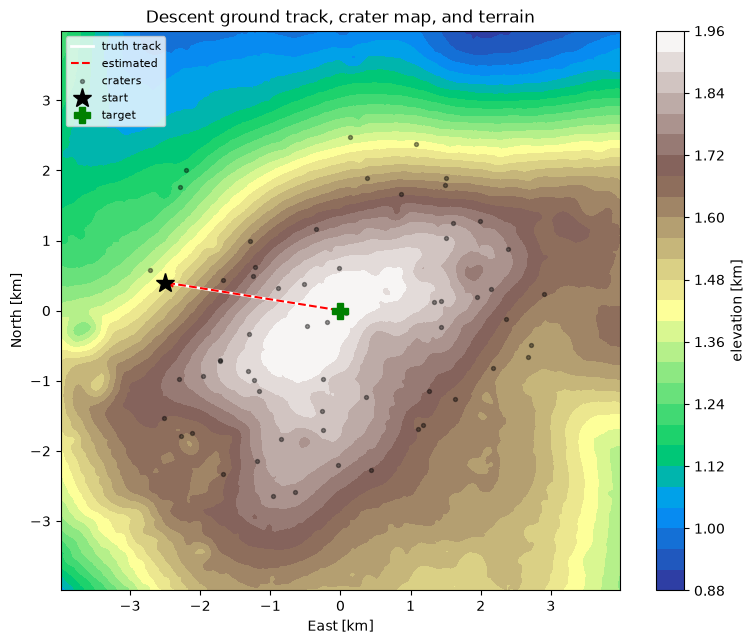

In [2]:
cx, cy = dem_x.mean(), dem_y.mean()
Xc = (dem_x - cx) / 1e3
Yc = (dem_y - cy) / 1e3

fig, ax = plt.subplots(figsize=(8, 6.5))
cf = ax.contourf(Xc, Yc, dem_z / 1e3, levels=30, cmap="terrain")
plt.colorbar(cf, ax=ax, label="elevation [km]")
ax.plot(
    s["traj_truth_x"] / 1e3, s["traj_truth_y"] / 1e3, "w-", lw=2, label="truth track"
)
ax.plot(s["traj_est_x"] / 1e3, s["traj_est_y"] / 1e3, "r--", lw=1.5, label="estimated")
ax.scatter(
    craters["east_m"] / 1e3,
    craters["north_m"] / 1e3,
    s=8,
    c="k",
    alpha=0.4,
    label="craters",
)
ax.plot(
    s["traj_truth_x"].iloc[0] / 1e3,
    s["traj_truth_y"].iloc[0] / 1e3,
    "k*",
    ms=14,
    label="start",
)
ax.plot(0, 0, "gP", ms=12, label="target")
ax.set_xlabel("East [km]")
ax.set_ylabel("North [km]")
ax.set_title("Descent ground track, crater map, and terrain")
ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 2. Altitude profile and altimeter performance

Truth vs. estimated height above the terrain during descent, and the number of craters tracked per epoch.

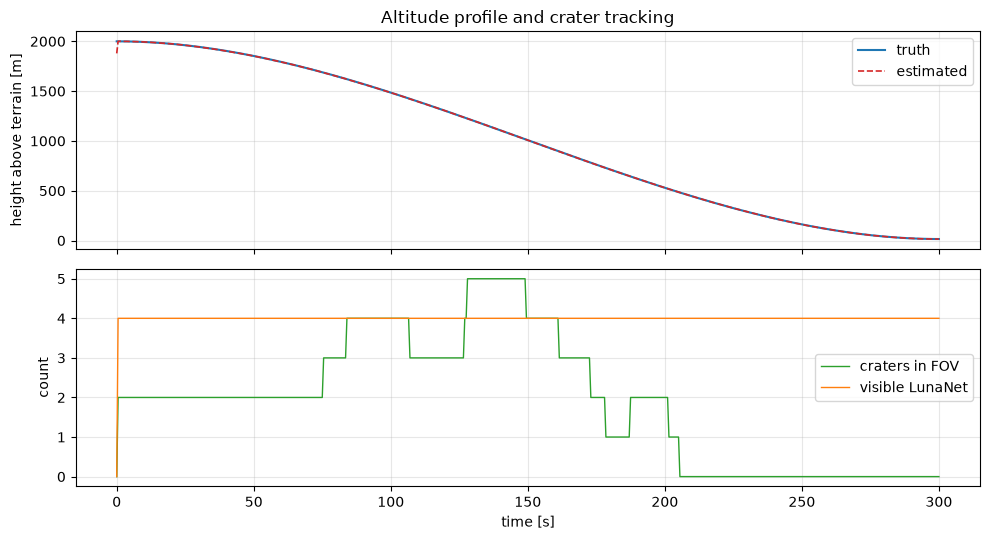

In [3]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
a1.plot(t, s["alt_truth"], "C0", lw=1.5, label="truth")
a1.plot(t, s["alt_est"], "C3--", lw=1.2, label="estimated")
a1.set_ylabel("height above terrain [m]")
a1.grid(alpha=0.3)
a1.legend()
a1.set_title("Altitude profile and crater tracking")
a2.plot(t, s["n_craters"], "C2", lw=1, label="craters in FOV")
a2.plot(t, s["n_visible_sat"], "C1", lw=1, label="visible LunaNet")
a2.set_ylabel("count")
a2.set_xlabel("time [s]")
a2.grid(alpha=0.3)
a2.legend()
plt.tight_layout()
plt.show()

## 3. Position error vs. filter 3σ (East / North / Up)

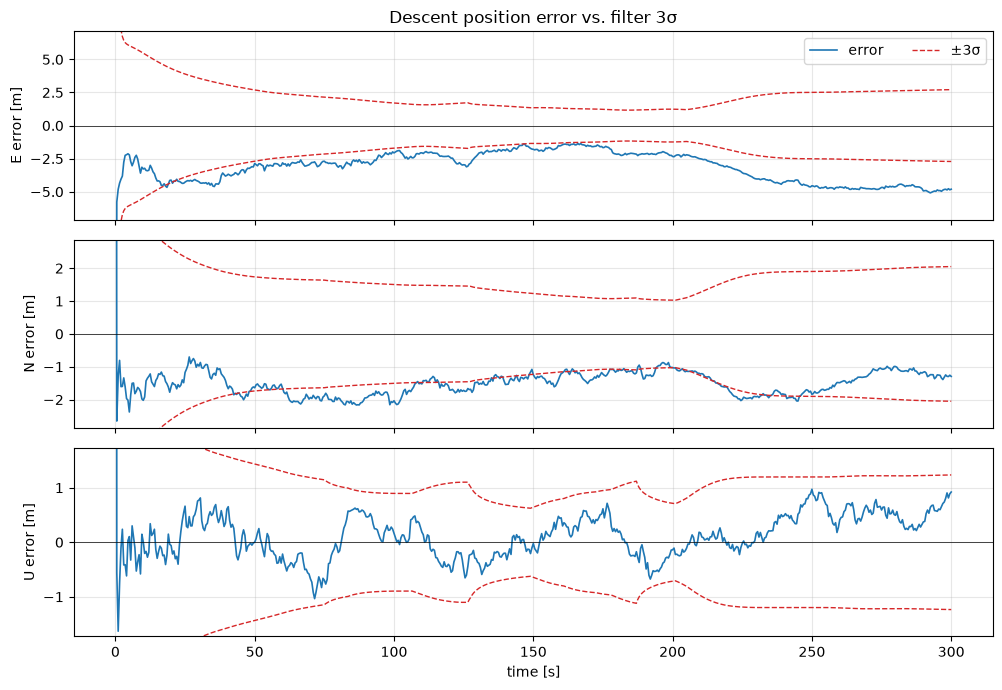

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, (lbl, ec, sc) in zip(
    axes,
    [
        ("E", "pos_err_x", "pos_sigma_x"),
        ("N", "pos_err_y", "pos_sigma_y"),
        ("U", "pos_err_z", "pos_sigma_z"),
    ],
):
    ax.plot(t, s[ec], "C0", lw=1.2, label="error")
    ax.plot(t, 3 * s[sc], "C3--", lw=1, label="±3σ")
    ax.plot(t, -3 * s[sc], "C3--", lw=1)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_ylabel(f"{lbl} error [m]")
    ax.grid(alpha=0.3)
    zoom_ylim(ax, s[ec], 3 * s[sc])
axes[0].legend(loc="upper right", ncol=2)
axes[-1].set_xlabel("time [s]")
axes[0].set_title("Descent position error vs. filter 3σ")
plt.tight_layout()
plt.show()

## 4. IMU bias and attitude estimation

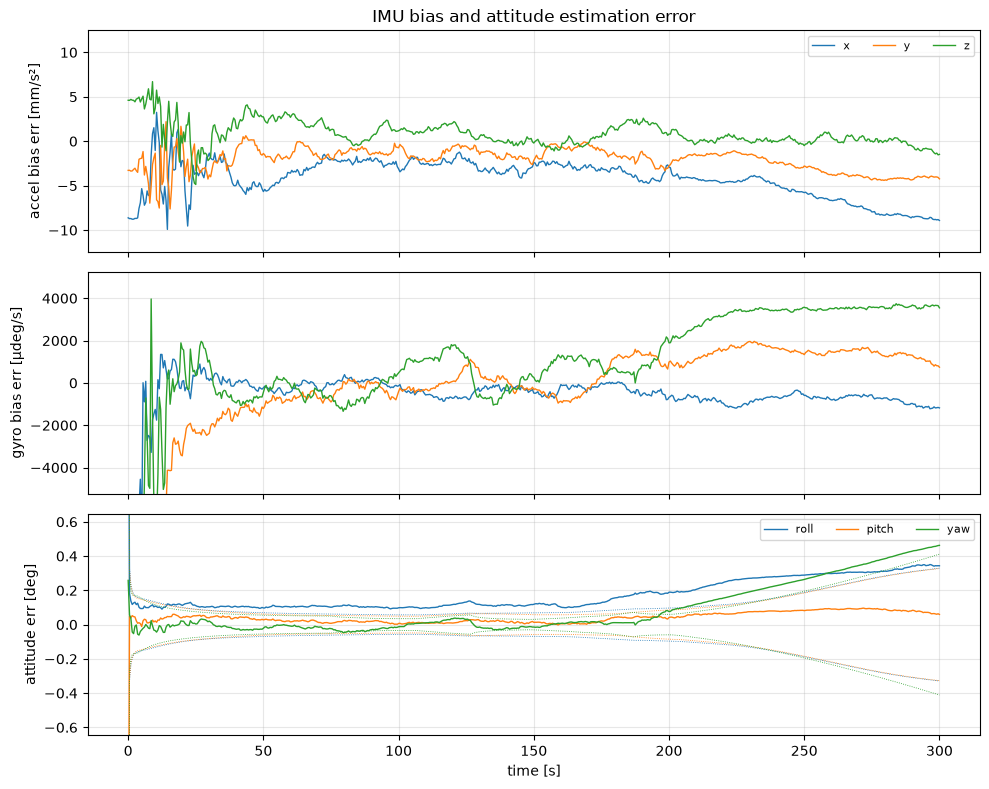

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for c, col in zip("xyz", ["C0", "C1", "C2"]):
    axes[0].plot(t, s[f"accel_bias_err_{c}"] * 1e3, col, lw=1, label=f"{c}")
    axes[1].plot(
        t, s[f"gyro_bias_err_{c}"] * 1e6 * 180 / np.pi, col, lw=1, label=f"{c}"
    )
    axes[2].plot(
        t,
        s[f"att_err_deg_{c}"],
        col,
        lw=1,
        label=["roll", "pitch", "yaw"]["xyz".index(c)],
    )
    axes[2].plot(t, 3 * s[f"att_sigma_deg_{c}"], col, lw=0.6, ls=":")
    axes[2].plot(t, -3 * s[f"att_sigma_deg_{c}"], col, lw=0.6, ls=":")
axes[0].set_ylabel("accel bias err [mm/s²]")
axes[0].legend(ncol=3, fontsize=8)
axes[1].set_ylabel("gyro bias err [µdeg/s]")
axes[2].set_ylabel("attitude err [deg]")
axes[2].legend(ncol=3, fontsize=8)
for ax in axes:
    ax.grid(alpha=0.3)
zoom_ylim(axes[0], *[s[f"accel_bias_err_{c}"] * 1e3 for c in "xyz"])
zoom_ylim(axes[1], *[s[f"gyro_bias_err_{c}"] * 1e6 * 180 / np.pi for c in "xyz"])
zoom_ylim(
    axes[2],
    *[s[f"att_err_deg_{c}"] for c in "xyz"],
    *[3 * s[f"att_sigma_deg_{c}"] for c in "xyz"],
)
axes[-1].set_xlabel("time [s]")
axes[0].set_title("IMU bias and attitude estimation error")
plt.tight_layout()
plt.show()

## 5. What does each sensor buy? (ablation study)

Final 3D position error with each aiding source disabled in turn: craters → horizontal, altimeter → vertical, LunaNet → absolute position.

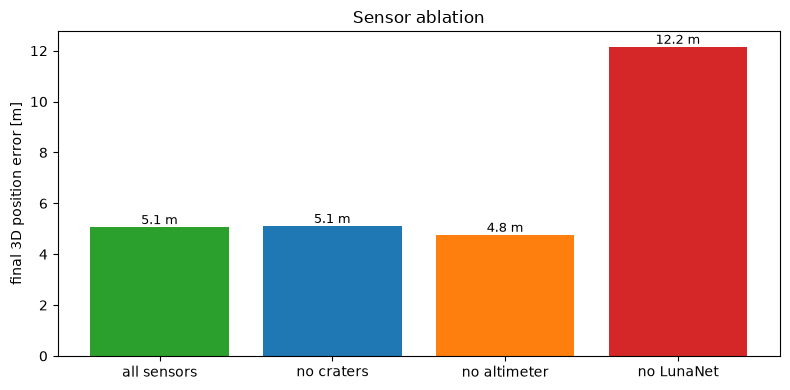

      config  final_pos_err_norm_m
 all sensors              5.064209
  no craters              5.107854
no altimeter              4.762747
  no LunaNet             12.154069


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["C2", "C0", "C1", "C3"]
ax.bar(ablation["config"], ablation["final_pos_err_norm_m"], color=colors)
for i, v in enumerate(ablation["final_pos_err_norm_m"]):
    ax.text(i, v, f"{v:.1f} m", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("final 3D position error [m]")
ax.set_title("Sensor ablation")
plt.tight_layout()
plt.show()
print(ablation.to_string(index=False))

## Summary

A `LanderNavApp` (an INS MEKF), co-hosted with a `LanderGncApp` (guidance) on a thin `Lander` agent, fuses IMU + radar altimeter + crater bearings + LunaNet pseudoranges over a powered descent, estimating the IMU biases online. The scenario is described in `configs/lander_nav.yaml`; a guidance-law trajectory can be injected as truth via the guidance app's `set_reference_trajectory_enu(...)` before `sim.run()`. The ablation shows each aiding source's distinct contribution — craters constrain horizontal position, the altimeter the vertical channel, and LunaNet the absolute position and clock.